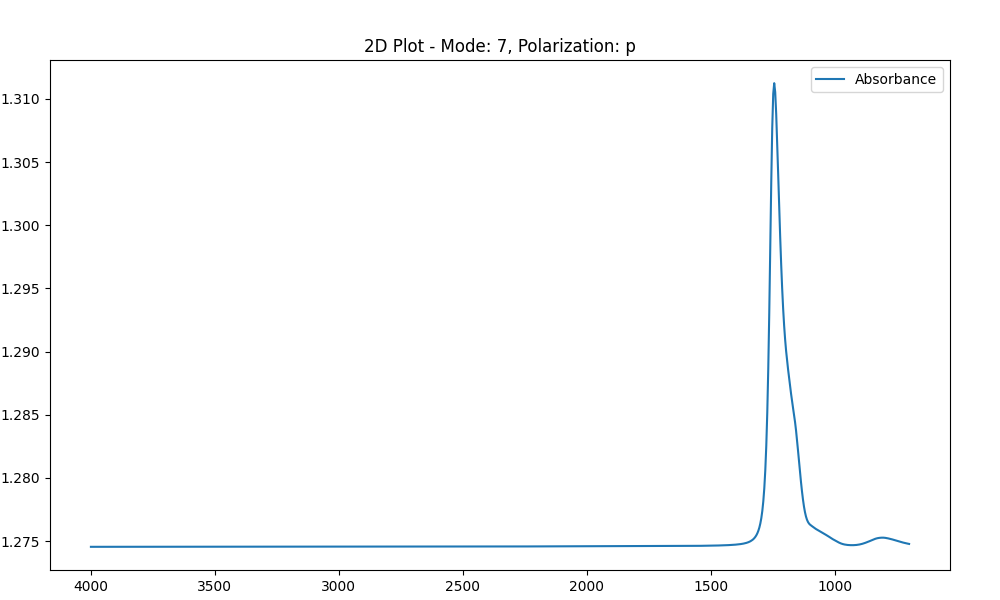

In [36]:
#0:  Here are all my import statements
%matplotlib widget 
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd     
from mpl_toolkits.mplot3d import Axes3D

#1: Here is were you upload your exell file. The path depends on your specific computer. to upload a .csv change to pd.read_csv
df = pd.read_excel("./Fresnell.xlsx")   

#2: This puts Exell columns into arrays. Exell Collums must be set up using these exact names (wave_numbers, n0,n1,n2,k0,k1,k2) for python to read correctly.  
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values
n2_array = df["n2"].values
k2_array = df["k2"].values 

#3: Basic functions defined for use
def cos(th):
    return np.cos(th*np.pi/180) 
def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 
def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 
def sin(th):
    return np.sin(th*np.pi/180) 

#4: Returns transmitted angle from incident angle. It gives you theta t from theta i. 
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))



#5: General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 
def t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

#6: General form of fresnel coefficients for p polarized light (parrallel electric field)  
def r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))
def t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#7: transmission matrix for P poloarized light. It relates the electric field on both sides of an interface. 
def D_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)],[r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7),1]])))  
#8: transmission matrix for S poloarized light. It relates the electric field on both sides of an interface. 
def D_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)],[r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7),1]])))  


#9: propagation matrix that relates electric field on both ends of the same medium. This is independant of polarazation.
def P(ni, nt, ki, kt, thi, d, Wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength),0],[0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength)]]))


#10: the total fresnell coefficients. Used to relate to total amount of electric field transmitted or reflected in relation to incident electric field. 
# This is currently simulating a two interface system. More can easily be added but updates will need to be made to graphing code and exell file import code. 
def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11)  
def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   
def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 
def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)  

#11: Here is an interactive plot of the fresnell Coefficients at a single interface plotted over theta. This will use only the general fresnell eqautions. 
# it will not call our matrix functions nor will it take values from the exell file
def funcPlot1(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5)) #
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000) #Creates a list of values for theta from 0 to 90 degrees.
    line01, = ax0.plot([],[], 'r--') #Creates 4 lines of empty lists for func1, func2, func3, func4 to populate. 
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$') #labels x axis
    ax0.set_ylabel('amplitude coefficient')  #labels y axis
    ax0.legend([r'rperp, r$_s$', r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)   #Creates a legend for our graph lines
    def plot(ni=1, nt=1.5, ki=0, kt=0):
        output1 = func1(ni, nt, ki, kt, thi) #Creates 4 output lists of numbers based off the functions we define when we call the Graph 
        output2 = func2(ni, nt, ki, kt, thi)
        output3 = func3(ni, nt, ki, kt, thi)
        output4 = func4(ni, nt, ki, kt, thi)
        line01.set_data(thi, output1)  #Tells the output lists were to go 
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1), ki=(0,5,.1), kt=(0,5,.1))   #Creates a value for our variables
#This will call funcplot1. I am going to comment it out to save CPU power. 
#funcPlot1(r_s, t_s, r_p, t_p) 
def mag_r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    return (np.abs(r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7))) #these functions find the real part of our complex coeeficients. 
def mag_r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    return (np.abs(r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7))) 
def mag_t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    return (np.abs(t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7))) 
def mag_t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    return (np.abs(t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)))  
#if you dont want the complex value and only want to graph the magitude un-comment the following. 
#funcPlot1(mag_r_s, mag_t_s, mag_r_p, mag_t_p)


#12 Here is plotting functions for the reflectance and transmittence. "big R & Big T" 

def funcPlot2(func1, func2, func3, func4): #same plotting structure as funcplot1. Just has different labels and when you call it you input Rperp, Tperp, Rpara, Tpara
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((0,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('Reflectance and Transmittance')
    ax0.legend([r'Rperp, R$_s$', r'Tperp, T$_s$', r'Rpara, R$_p$', r'Tpara, T$_p$'],)
    def plot(ni=1, nt=1.5, ki=0, kt=0):
        output1 = func1(ni, nt, ki, kt, thi)
        output2 = func2(ni, nt, ki, kt, thi)
        output3 = func3(ni, nt, ki, kt, thi)
        output4 = func4(ni, nt, ki, kt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.01), nt=(0,5,.01), ki=(0,5,.01), kt=(0,5,.01))

def Rperp(ni, nt, ki, kt, thi):    #Caulculates Rperp from r_s
    r = r_s(ni, nt, ki, kt, thi)
    return(r*r.conjugate())

def Rpara(ni, nt, ki, kt, thi):    #Caulculates Rpara from r_p
    r = r_p(ni, nt, ki, kt, thi)
    return(r*r.conjugate())

def Tperp(ni, nt, ki, kt, thi):     #Caulculates Tperp from t_s
    cos_tht = costht(ni, nt, ki, kt, thi)
    t = t_s(ni, nt, ki, kt, thi)
    return(((nt+1j*kt)*cos_tht/(ni+1j*ki)/cos(thi))*t*t.conjugate())

def Tpara(ni, nt, ki, kt, thi):     #Caulculates Tpara from t_p
    cos_tht = costht(ni, nt, ki, kt, thi)
    t = t_p(ni, nt, ki, kt, thi)
    return(((nt+1j*kt)*cos_tht/(ni+1j*ki)/cos(thi))*t*t.conjugate())  
# T = np.real((n2 * cos_th2) / (n0 * cos_th0)) * np.abs(t)**2 this can be used and will graph the same result but gets around the complex value warning
#This will call funcplot2. I am going to comment it out to save CPU power. 
#funcPlot2(Rperp, Tperp, Rpara, Tpara)   


#13: This phaseplot will show the phase shift at a single interface 

def phase_shift(array):  #this function finds the phase shift by taking the inverse tangent of the real divided by the imaginary part of our fresnell coeeficients.
    return(np.angle(array))  

def phasePlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-np.pi,np.pi))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('phase shift')
    ax0.legend([r'rperp, r$_s$',r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)
    def plot(ni=1, nt=1.5, ki=0, kt=0):
        output1 = phase_shift(func1(ni, nt, ki, kt, thi))
        output2 = phase_shift(func2(ni, nt, ki, kt, thi))
        output3 = phase_shift(func3(ni, nt, ki, kt, thi))
        output4 = phase_shift(func4(ni, nt, ki, kt, thi))
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.01), nt=(0,5,.01), ki=(0,5,.01), kt=(0,5,.01))   
#This will call phaseplot. I am going to comment it out to save CPU power. 
#phasePlot(r_s, t_s, r_p, t_p)


#14 Here is code that plots the decay of the evanescent wave. This happens when our incident angle is beyond the critical angle.  

def Evanescentdecayplot(func1,):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(42,89.9,10000)
    line01, = ax0.plot([],[], 'r-')
    ax0.set_xlim((0,1000))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'y')
    ax0.set_ylabel('E_t amplitude')
    ax0.legend([r'Re(E_t)',],)
    def plot(ni=1.5, nt=1, x=0, thi=43):
        y = np.linspace(0.1, 1000, 10000)
        output1 = func1(ni, nt, y, x, thi)
        line01.set_data(y, output1)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1), x=(0,1000,.1), thi=(43,89.9,.1))  
#this function calculates the amplitude of the electric field across the boundry under the condition thi > th_critical 
def ReE_t(ni, nt, y, x, thi, lamb_0=800, E_0t=1):
    return(E_0t*np.exp((-2*np.pi*nt)/(lamb_0)*((ni**2)/(nt**2)*(sin(thi))**2-1)**(1/2)*y)*(np.cos(np.pi*2/lamb_0*x*sin(thi)))) 
#This will call Evanescentdecayplot. I am going to comment it out to save CPU power.
#Evanescentdecayplot(ReE_t)  

#15 this code will plot the magnitude of the total fresnell coefficients at 2 parrallel interfaces. 
def totalFresnalcoeffPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    th0 = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperptotal, r$_s$', r'tperptotal, t$_s$', r'rparatotal, r$_p$', r'tparatotal, t$_p$'],)
    def plot(n0=1, n1=1.4, n2=1.5, k0=0, k1=0, k2=0, d=1, Wavelength=4):
        output1 = func1(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output2 = func2(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output3 = func3(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output4 = func4(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        line01.set_data(th0, output1)
        line02.set_data(th0, output2)
        line03.set_data(th0, output3)
        line04.set_data(th0, output4)
        plt.draw()
    interact(plot, n0=(0,5,.1), n1=(0,5,.1), n2=(0,5,.1), k0=(0,5,.1), k1=(0,5,.1), k2=(0,5,.1), d=(0,5,.1), Wavelength=(0,5,.1))  
#These are the total fresnell coeefecients. All of this can be done using the transer matrix method but it slows the code down by a factor of 100 causing the sliders to be choppy. 
def t_s_total(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    t_s_nin0_ntn1 = t_s(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    t_s_nin1_ntn2 = t_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    r_s_nin1_ntn0 = r_s(n1, n0, k1, k0, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_s_nin1_ntn2 = r_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    return((t_s_nin0_ntn1*np.exp(1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_s_nin1_ntn2)/(1-r_s_nin1_ntn0*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*r_s_nin1_ntn2))
def r_s_total(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    r_s_nin0_ntn1 = r_s(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_s_nin1_ntn2 = r_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_s_nin1_ntn0 = r_s(n1, n0, k1, k0, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_s_nin1_ntn2 = r_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    t_s_nin0_ntn1 = t_s(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    t_s_nin1_ntn2 = t_s(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    return(r_s_nin0_ntn1+((np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_s_nin0_ntn1*r_s_nin1_ntn2*t_s_nin1_ntn2)/(1-r_s_nin1_ntn0*r_s_nin1_ntn2*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength))))  
def t_p_total(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    t_p_nin0_ntn1 = t_p(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    t_p_nin1_ntn2 = t_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    r_p_nin1_ntn0 = r_p(n1, n0, k1, k0, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_p_nin1_ntn2 = r_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    return((t_p_nin0_ntn1*np.exp(1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_p_nin1_ntn2)/(1-r_p_nin1_ntn0*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*r_p_nin1_ntn2))
def r_p_total(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    r_p_nin0_ntn1 = r_p(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_p_nin1_ntn2 = r_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_p_nin1_ntn0 = r_p(n1, n0, k1, k0, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    r_p_nin1_ntn2 = r_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    t_p_nin0_ntn1 = t_p(n0, n1, k0, k1, th0, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7) 
    t_p_nin1_ntn2 = t_p(n1, n2, k1, k2, th1, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    return(r_p_nin0_ntn1+((np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength)*t_p_nin0_ntn1*r_p_nin1_ntn2*t_p_nin1_ntn2)/(1-r_p_nin1_ntn0*r_p_nin1_ntn2*np.exp(2*1j*2*np.pi*d*(n1+1j*k1)*cos_th1/Wavelength))))  
def mag_r_p_total(*args, **kwargs):
    return np.abs(r_p_total(*args, **kwargs))   
def mag_r_s_total(*args, **kwargs):
    return np.abs(r_s_total(*args, **kwargs))
def mag_t_p_total(*args, **kwargs):
    return np.abs(t_p_total(*args, **kwargs))
def mag_t_s_total(*args, **kwargs):
    return np.abs(t_s_total(*args, **kwargs)) 
#This will call totalFresnalcoeffPlot using explicit r and t eqautions. I am going to comment it out to save CPU power.
#totalFresnalcoeffPlot(mag_r_p_total, mag_r_s_total, mag_t_s_total, mag_t_p_total)

#Notice! p_tot and s_tot refer to fresnell coeeficiencts obtained through matrix method. p_total and s_total are the fresnell coeefecients obtained by solving for them at 2 parrallel interface. 
def matrix_r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def matrix_r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def matrix_t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_p_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def matrix_t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

#if you want to call the same plot using the matrix method uncomment the following 
#totalFresnalcoeffPlot(matrix_r_p_tot, matrix_r_s_tot, matrix_t_s_tot, matrix_t_p_tot)





#spectra plot. The n and k values in this come from the imported exell file. Make sure variable headings have been named correctly

# Mode 0 graphs n and k values for the n0 medium

# Mode 1 graphs n and k values for the n1 medium

# Mode 2 graphs n and k values for the n2 medium

# Mode 3 plots the fresnell coeeficints over wavelenght 

# mode 4 plots Reflectance. more specifically the (magnitude of r)^2 aka r*rconjugate  

# mode 5 plots Reflectance. more specifically the real part and the imaginary part. Re(r^2)  Im(r^2)

# mode 6 plots the absorbtance of the materiarial when the system has no net transmission. Im denoting it 'a'. From kirkoffs law a+T+R=1. 
# For example when a film is on metal t=0 so a+T+R=1=a+R. So we find a to be 1-R. 

# mode 7 plots the absorbance from the absorbtance of mode 6. I denoted it A it is just the log 1/a in this situation. The naming of these is confusing i did not choose them. 

# Mode 8 plots Trasmittence. Check your n and k values for the exell file to make sure your 3rd medium is capable of transmitting.

# mode 9 plots the Absorbance 'A' when there is transmission and reflection.   

#mode 10 shows the phase shift

# thats all the modes for now. There are tons of combination graphs I might make in the future like plotting n, k, and absoption all on the same graph. 

def Fresnellbkg(polarization, i):          #creates backround for our spectra calculation we arent using this now but may be useful later to ratio our spectra
    n0, n2 = n0_array[i], n2_array[i]
    k0, k2 = k0_array[i], k2_array[i]
    # wavelength = 10000 / wave_numbers[i] # wave_number is in cm^-1 and this calculates wavelength in um
    if polarization == 'p':
        return r_p(n0, n2, k0, k2, 80, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7), t_p(n0, n2, k0, k2, 80, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)
    else:
        return r_s(n0, n2, k0, k2, 80, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7), t_s(n0, n2, k0, k2, 80, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7)



def Spectraplot(wave_numbers, n0_array, n1_array, n2_array,k0_array, k1_array, k2_array, d, th0, mode='0', polarization='p'):
    plt.figure(figsize=(10, 6))
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.gca().invert_xaxis()

    def Fresnell_rtot_ttot(polarization, i):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        wavelength = 1 / wave_numbers[i] # wave_number is in cm^-1 so this makes wavelength in cm which means that d needs to be in cm
        if polarization == 'p':
            return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
        else:
            return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  


    if mode == '0':
        plt.plot(wave_numbers, n0_array, label='n0')
        plt.plot(wave_numbers, k0_array, label='k0')
        plt.ylabel('Optical constants')
    
    
    elif mode == '1':
        plt.plot(wave_numbers, n1_array, label='n1')
        plt.plot(wave_numbers, k1_array, label='k1')
        plt.ylabel('Optical constants')
    
    
    elif mode == '2':
        plt.plot(wave_numbers, n2_array, label='n2')
        plt.plot(wave_numbers, k2_array, label='k2')
        plt.ylabel('Optical constants')
    
    elif mode == '3':
        r_list, t_list = [], []
        for i in range(len(wave_numbers)):
            r, t = Fresnell_rtot_ttot(polarization, i)   
            r_list.append(np.real(r))
            t_list.append(np.real(t))
        plt.plot(wave_numbers, r_list, label='r total')
        plt.plot(wave_numbers, t_list, label='t toal')
        plt.ylabel('Fresnell Coefficients') 
  
    elif mode == '3.5':
        r_list, t_list = [], []
        for i in range(len(wave_numbers)):
            r, t = Fresnell_rtot_ttot(polarization, i)   
            r_list.append(np.abs(r))
            t_list.append(np.abs(t))
        plt.plot(wave_numbers, r_list, label='r total')
        plt.plot(wave_numbers, t_list, label='t toal')
        plt.ylabel('Fresnell Coefficients')
     
    
    elif mode == '4':
        R = []
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value. 
            R.append(np.abs(r)**2)
        plt.plot(wave_numbers, R, label='R')
        plt.ylabel('Reflectance---|r|^2')   
    
    elif mode == '5':
        RealR,  ImR = [], []
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value. 
            RealR.append(np.real(r**2))
            ImR.append(np.imag(r**2))
        plt.plot(wave_numbers, RealR, label='Real') 
        plt.plot(wave_numbers, ImR, label='Imagenary')
        plt.ylabel('Reflectance---real vs imaginary')     

    elif mode == '6':
        Absorbtance = [] # creates empty list to store entries
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value.  
            R = np.abs(r)**2
            a = 1 - R 
            Absorbtance.append(a)    #adds an entry to the list 
        plt.plot(wave_numbers, Absorbtance, label='Absorbtance') 
        plt.ylabel('Absorbtance')    
   
    elif mode == '7':
        Absorbance = [] # creates empty list to store entries
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value.  
            R = np.abs(r)**2
            a = 1 - R
            A = np.log10(1/a)
            Absorbance.append(A)    #adds an entry to the list 
        plt.plot(wave_numbers, Absorbance, label='Absorbance') 
        plt.ylabel('Absorbance')    
    
    elif mode == '8':
        Transmittence = [] #creates empty list to store entries
        for i in range(len(wave_numbers)):
            n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]     # need to redefine variables inside of loop
            k0, k1, k2 = k0_array[i], k0_array[i], k2_array[i]
            cos_th0 = cos(th0)
            th1 = snells(n0, n1, k0, k1, th0)  #Im recaulculating theta 1 and 2 in the loop because they depend on n and k wich vary per wavelength.
            cos_th1 = cos(th1) 
            th2 = snells(n1, n2, k1, k2, th1)
            cos_th2= cos(th2) 
            
            _, t = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the r value.  
            T = np.real((n2 * cos_th2) / (n0 * cos_th0)) * np.abs(t)**2
            Transmittence.append(T)    #adds an entry to the list 
        plt.plot(wave_numbers, Transmittence, label='Transmittence') 
        plt.ylabel('Transmittence')     

    elif mode == '9':
        Absorbance = [] #creates empty list to store entries
        for i in range(len(wave_numbers)):
            n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]     # need to redefine variables inside of loop
            k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]    # corrected here for k1 which was k0 before
            cos_th0 = cos(th0)
            th1 = snells(n0, n1, k0, k1, th0)  #Im recaulculating theta 1 and 2 in the loop because they depend on n and k wich vary per wavelength.
            cos_th1 = cos(th1) 
            th2 = snells(n1, n2, k1, k2, th1)
            cos_th2= cos(th2) 
            r, t = Fresnell_rtot_ttot(polarization, i)     
            T = np.real((n2 * cos_th2) / (n0 * cos_th0)) * np.abs(t)**2 
            R = np.abs(r)**2 
            a = 1 - R -T 
            A = np.log10(1/a)
            Absorbance.append(A)    #adds an entry to the list 
        plt.plot(wave_numbers, Absorbance, label='Absorbance') 
        plt.ylabel('Absorbance')    
    
    elif mode == '10':
        phase = []
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)
            phase.append(np.angle(r))
        plt.plot(wave_numbers, phase, label='arg(r)')
        plt.ylabel('Phase of r')

    else:
        plt.text(0.5, 0.5, f"Unsupported mode: {mode}", ha='center')
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.title(f"2D Plot - Mode: {mode}, Polarization: {polarization}")
    plt.legend()
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.90)
    plt.show()

#uncomment to graph spectraplot
#Spectraplot(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=.000001, th0=80, mode='7', polarization='s') 
Spectraplot(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=.00000001005, th0=80, mode='7', polarization='p') 

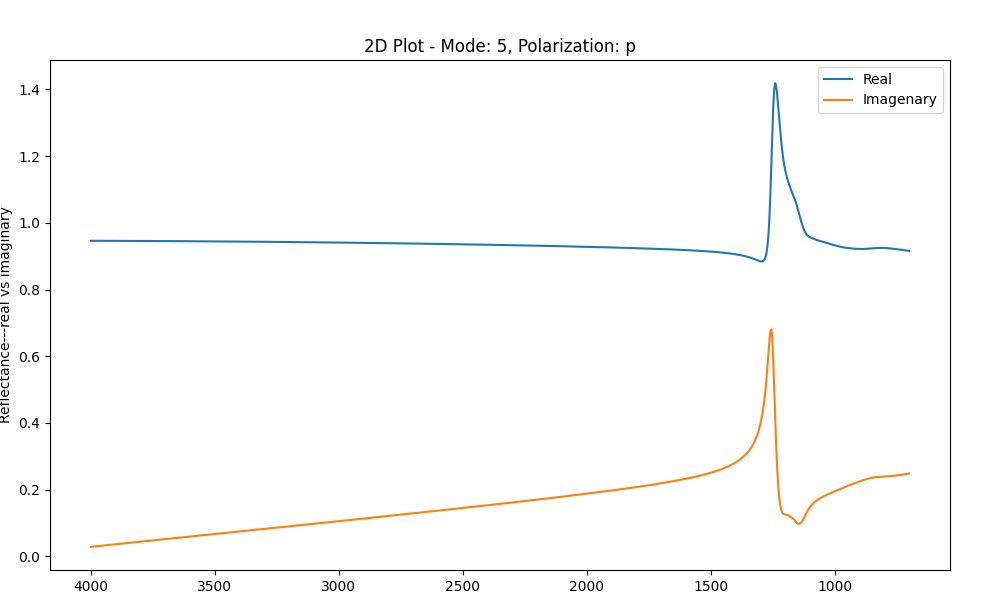

In [ ]:
#here's a 3d graph. its probably not very helpful but its kinda cool 

from mpl_toolkits.mplot3d import Axes3D

def plot_3D(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d, th0, mode='4', polarization='p', view = 'xy'):
    
    def Fresnell_rtot_ttot(polarization, i):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        wavelength = 10000 / wave_numbers[i]
        if polarization == 'p':
            return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
        else:
            return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  
   
    
    fig = plt.figure(figsize=(10, 7))              #Creating my graphing figure
    ax = fig.add_subplot(111, projection='3d')

    
    if mode == '0':
        ax.set_ylabel('n1')
        ax.set_zlabel('k1')
        ax.set_title(f'Complex index')
        ax.plot(wave_numbers, n1_array, k1_array, label=f'Complex refractive index')

    if mode == '1':
        r_Re_list, r_Im_list, t_Re_list, t_Im_list  = [], [], [], []
        for i in range(len(wave_numbers)):
            r, t = Fresnell_rtot_ttot(polarization, i)   
            r_Re_list.append(np.real(r))
            r_Im_list.append(np.imag(r))        
            #t_Re_list.append(np.real(t))
            #t_Im_list.append(np.imag(t))              
        
        ax.set_ylabel('Real')
        ax.set_zlabel('Imaginary')
        ax.set_title(f'Complex r and t')
        #ax.plot(wave_numbers, t_Re_list, t_Im_list, label=f'Complex t')
        ax.plot(wave_numbers, r_Re_list, r_Re_list, label=f'Complex r')  

    #ax.set_title(f'Complex {polarization}-polarized reflection coefficient vs. wavenumber') {} lets the name change based on mode
          

    else:
        ax.text(0.5, 0.5, 0.5, f"Unsupported mode: {mode}", ha='center')
  
    
    #this allows us to choose a viewing axis    
    if view == 'xy':
        ax.view_init(elev=90, azim=-90)  
    elif view == 'xz':
        ax.view_init(elev=0, azim=0)    
    elif view == 'yz':
        ax.view_init(elev=0, azim=90)    
    elif view == 'isometric':
        ax.view_init(elev=30, azim=45)   
  
   

    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.invert_xaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()   

# plot_3D(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=0.001, th0=80, mode='0', polarization='p', view='isometric')

In [2]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
